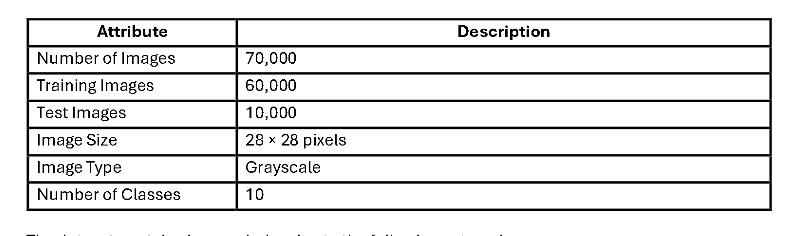


will build a Convolutional Neural Network (CNN) using the FashionMNIST Dataset to classify images of clothing into different categories.

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [3]:
#loading the MNIST Dataset
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("Training Images :", len(x_train))
print("Testing Images  :", len(x_test))
print("Training Shape  :", x_train.shape) #60,000 images for training purpose with 28x28 dimention
print("Testing Shape   :", x_test.shape) #10,000 images for testing purpose with 28x28 dimention

Training Images : 60000
Testing Images  : 10000
Training Shape  : (60000, 28, 28)
Testing Shape   : (10000, 28, 28)


In [5]:
y_train[0:5] #0 to 5 image label with type int

array([9, 0, 0, 3, 0], dtype=uint8)

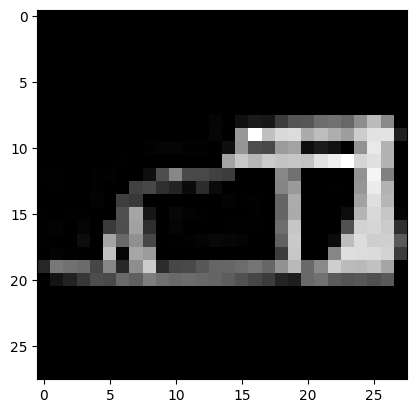

In [6]:
#visualizing a sample image from the data
plt.imshow(x_train[435],cmap='gray')

In [7]:
sample_image=x_train[200]

In [8]:
print("pixelated image",sample_image[:,:])

pixelated image [[  0   0   0   0   0   0   0   0   0   0   0   0   0  82 122  37   0   5
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   2   0  38 100  28 121   0   1
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   5   0  86  43   0 136  15   0
    2   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   2   0 104  30   0 102  40   0
    3   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   3   0   0 111   2   0  73  81   0
    4   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   2   0  17  87   0   0  45  81   0
    4   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4   0  54  90   0   0  24  92   0
    4   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   3   0  76  30   0   0   0  93   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   1   0  7

In [9]:
#1Normalize the image pixel values.
x_train_norm=x_train.astype('float32')/255.0 #all the 60k images are getting normalized
x_test_norm=x_test.astype('float32')/255.0 #all the 10k images are getting normalized

In [10]:
one_image=x_train_norm[0:1]
print(one_image) #the image is of size 28x28

[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
  

In [11]:
#Reshape the images to make them compatible with CNN layers.
x_train_cnn=np.expand_dims(x_train_norm,axis=-1)

In [12]:
x_test_cnn=np.expand_dims(x_test_norm, axis=-1)

In [13]:
x_train_cnn.shape

(60000, 28, 28, 1)

In [14]:
x_test_cnn.shape

(10000, 28, 28, 1)

In [15]:
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

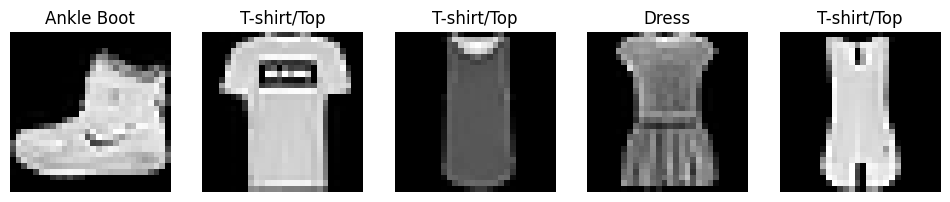

In [16]:
#Display at least five sample images along with their class labels.
plt.figure(figsize=(12,3))

for i in range(5):
    plt.subplot(1,5,i+1)

    # squeeze() removes the extra channel dimension.
    # Shape changes from (28,28,1) -> (28,28)
    # Matplotlib expects a 2D array for grayscale images.
    plt.imshow(x_train_cnn[i].squeeze(), cmap="gray")

    plt.title(class_names[y_train[i]])

    # Hide the x-axis and y-axis numbers/ticks
    # This makes the image display cleaner.
    plt.axis("off")

plt.show()

In [17]:
# Assignment part 2

#2.1

from tensorflow.keras import layers, models

In [18]:
#2.3  # Create a Sequential CNN model
# Building the CNN Image Classifier

model = models.Sequential([

    # Input layer for 28x28 grayscale images
    layers.Input(shape=(28,28,1), name="input_layer"),

    # Extract basic image features using 16 filters
    layers.Conv2D(filters=16, kernel_size=(3,3),
                  activation='relu',
                  name="conv_layer_1"),

    # Reduce feature map size to decrease computation
    layers.MaxPool2D(pool_size=(2,2),
                     name="max_pool_1"),   # Output: (13,13,16)

    # Learn more complex features using 32 filters
    layers.Conv2D(filters=32, kernel_size=(3,3),
                  activation='relu',
                  name="conv_layer_2"),

    # Further reduce feature map size
    layers.MaxPool2D(pool_size=(2,2),
                     name="max_pool_2"),   # Output: (5,5,32)

    # Convert 3D feature maps into a 1D vector
    layers.Flatten(name="flatten_layer"),  # 5×5×32 = 800

    # First hidden layer to learn patterns
    layers.Dense(64,
                 activation='relu',
                 name="hidden_layer_1"),

    # Second hidden layer for deeper learning
    layers.Dense(32,
                 activation='relu',
                 name="hidden_layer_2"),

    # Output layer to classify images into 10 classes
    layers.Dense(units=10,
                 activation='softmax',
                 name="output_layer")
])


In [19]:
# 2.5 compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
# 3 train the model
# Train the CNN model using the training dataset
history = model.fit(
    x_train_cnn,          # Training images
    y_train,              # Training labels
    epochs=10,            # Train the model for 10 iterations
    batch_size=32,        # Process 32 images at a time
    validation_split=0.2  # Use 20% of training data for validation
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7950 - loss: 0.5624 - val_accuracy: 0.8533 - val_loss: 0.4094
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8632 - loss: 0.3766 - val_accuracy: 0.8691 - val_loss: 0.3590
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8809 - loss: 0.3276 - val_accuracy: 0.8756 - val_loss: 0.3398
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8882 - loss: 0.2992 - val_accuracy: 0.8823 - val_loss: 0.3213
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8992 - loss: 0.2735 - val_accuracy: 0.8822 - val_loss: 0.3113
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9070 - loss: 0.2530 - val_accuracy: 0.8893 - val_loss: 0.2996
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9122 - loss: 0.2374 - val_accuracy: 0.8972 - val_loss: 0.2895
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9178 -

In [21]:
# Display the final training accuracy
print("Final Training Accuracy:", history.history['accuracy'][-1])

# Display the final validation accuracy
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9274791479110718
Final Validation Accuracy: 0.8885833621025085


In [22]:
# Display selected training parameters
print("Epochs Selected :", 10)
print("Batch Size Selected :", 32)

Epochs Selected : 10
Batch Size Selected : 32


In [23]:
#Part 4 — Model Evaluation
# Evaluate the CNN model on the test dataset
test_loss, test_accuracy = model.evaluate(x_test_cnn, y_test)
# Display the test loss
print("Test Loss :", test_loss)

# Display the test accuracy
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8817 - loss: 0.3365
Test Loss : 0.33647045493125916
Test Accuracy : 0.8816999793052673


In [27]:
#Step 2: Generate Predictions
# Predict probabilities for all test images
predictions = model.predict(x_test_cnn)

# Convert probabilities into class labels
predicted_labels = np.argmax(predictions, axis=1)
print(predictions)
print(predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
[[2.63971844e-09 2.28212684e-08 2.76207790e-09 ... 3.15331417e-04
  4.09107592e-08 9.99531388e-01]
 [1.67250309e-05 9.49258987e-12 9.99651611e-01 ... 4.03968171e-16
  1.17142862e-09 4.55071636e-14]
 [9.76692616e-10 9.99999940e-01 1.32501354e-09 ... 1.25160593e-20
  1.08602926e-13 8.09323901e-17]
 ...
 [7.54065166e-09 5.57290282e-12 3.20488636e-11 ... 3.45477702e-14
  9.99999940e-01 2.67689679e-13]
 [1.44140202e-07 9.99995410e-01 1.37619722e-07 ... 1.90391106e-12
  3.38557378e-08 5.75711590e-10]
 [2.30299178e-04 7.50402080e-07 2.17801382e-04 ... 1.34457415e-03
  1.86620266e-04 2.60345929e-04]]
[9 2 1 ... 8 1 5]


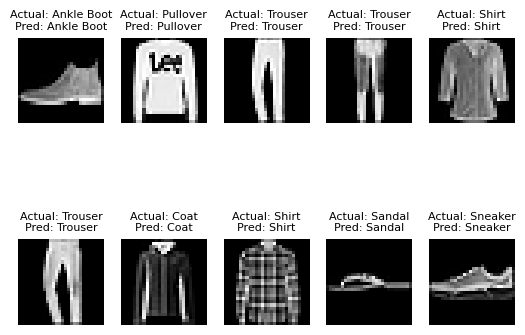

In [35]:
# Step 3: Display First 10 Test Images with Actual & Predicted Labels

for i in range(10):

    # Create a subplot (2 rows × 5 columns)
    plt.subplot(2,5,i+1)

    # Display the grayscale image
    plt.imshow(x_test_cnn[i].squeeze(), cmap="gray")

    # Display actual and predicted labels
    plt.title(
        f"Actual: {class_names[y_test[i]]}\nPred: {class_names[predicted_labels[i]]}",
        fontsize=8
    )

    # Hide axis values
    plt.axis("off")

# Show all images
plt.show()

In [32]:
# Step 4: Generate Confusion Matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
print(cm)

[[659   1   6  50  10   4 265   0   5   0]
 [  0 971   0  18   4   1   4   0   2   0]
 [ 10   0 757   9  88   0 133   0   3   0]
 [  4   2   7 907  36   0  41   0   3   0]
 [  1   1  28  20 858   0  91   0   1   0]
 [  0   0   0   0   0 983   0  13   0   4]
 [ 51   0  36  32  58   1 813   0   9   0]
 [  0   0   0   0   0  17   0 968   0  15]
 [  2   0   3   2   5   7  12   3 965   1]
 [  1   0   0   0   0  11   0  52   0 936]]


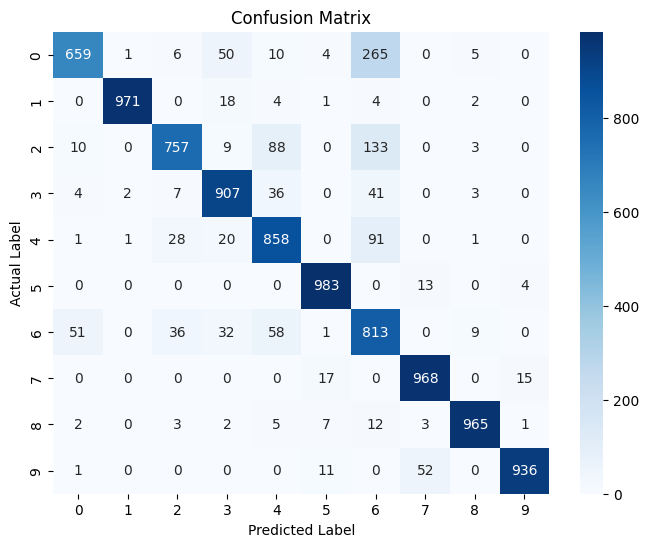

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

# Add axis labels
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add title
plt.title("Confusion Matrix")

# Display the confusion matrix
plt.show()

In [29]:
from sklearn.metrics import classification_report

# Display Precision, Recall and F1-score
print(classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/Top       0.91      0.66      0.76      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.90      0.76      0.82      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.81      0.86      0.83      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.60      0.81      0.69      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle Boot       0.98      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



#Part 5 – Model Analysis.

1. Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image classification?

Answer:

CNNs are more suitable for image classification because they automatically extract important features such as edges, shapes, and patterns from images using convolution layers. They also preserve the spatial relationships between pixels and require fewer parameters than ANNs, making them more efficient and accurate for image data. In contrast, ANNs require the image to be flattened into a 1D vector, which loses spatial information.

2. What is the purpose of a Convolution layer?

Answer:

The Convolution layer is used to extract important features from an image, such as edges, corners, textures, and shapes. It applies filters (kernels) that slide across the image to produce feature maps, which help the CNN learn meaningful patterns for image classification.

3. Why is Max Pooling used in CNNs?

Answer:

Max Pooling reduces the size of the feature maps by selecting the maximum value from each pooling region. This decreases computation, reduces memory usage, helps prevent overfitting, and retains the most important features detected by the convolution layer.

4. Why is the Flatten layer required before the Dense layers?

Answer:

The Flatten layer converts the multi-dimensional feature maps produced by the convolution and pooling layers into a one-dimensional vector. Dense (fully connected) layers require one-dimensional input, so Flatten acts as a bridge between the CNN feature extraction layers and the classification layers.

5. Why is the Softmax activation function used in the output layer?

Answer:

The Softmax activation function converts the output values into probabilities for each class. The probabilities sum to 1, and the class with the highest probability is selected as the final prediction. Since the Fashion-MNIST dataset has 10 classes, Softmax is suitable for multi-class classification.

6. How does the Adam optimizer help in training the CNN?

Answer:

The Adam (Adaptive Moment Estimation) optimizer updates the model's weights efficiently during training by automatically adjusting the learning rate for each parameter. It combines the advantages of Momentum and RMSProp, resulting in faster convergence, stable training, and improved accuracy.